# Linear Regression

## Day 3: train_test_split
Overfitting and underfitting, PolynomialFeatures.
Variance vs Bias. 

In [1]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler, PolynomialFeatures, KBinsDiscretizer, OneHotEncoder, OrdinalEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, GridSearchCV, train_test_split, cross_validate, KFold, cross_val_predict, RandomizedSearchCV
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_california_housing, load_iris, make_regression, load_breast_cancer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, mean_squared_error, r2_score, mean_absolute_error
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge, Lasso, ElasticNet, RidgeCV
from sklearn.feature_selection import SelectKBest, f_classif
import matplotlib.pyplot as plt
import random
from scipy.stats import loguniform
import scipy
import seaborn as sns
from scipy.interpolate import make_interp_spline

In [ ]:
lr = LinearRegression()
lasso = Lasso(alpha=0.1)
ridges = Ridge(alpha=0.1)
eln = ElasticNet(alpha=0.1)
np.random.seed(42)
X = np.random.rand(100, 5)
y = 5*X[:,0] + 3*X[:,1] + np.random.randn(100) * 0.1

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
lr.fit(X_train, y_train)
print(f"Linear Coefs: {lr.coef_}") # Assigns useless coefficients to random data. 
lasso.fit(X_train, y_train)
print(f"Lasso Coeffs: {lasso.coef_}") # Identifies useful features and zeros out the rest.
ridges.fit(X_train, y_train)
print(f"Ridge Coeffs: {ridges.coef_}") 
eln.fit(X_train, y_train)
print(f"ElasticNet Coeffs: {eln.coef_}")

Linear Coefs: [ 4.96529587  2.97660767  0.06479033  0.01455846 -0.04456402]
Lasso Coeffs: [ 3.73179063  1.74766801 -0.          0.         -0.        ]
Ridge Coeffs: [ 4.88981981  2.92846016  0.05387682  0.02082963 -0.05377388]
ElasticNet Coeffs: [ 2.74190793  1.41325398 -0.          0.         -0.        ]


In [5]:
X, y, true_coeffs = make_regression(
    n_samples=200,
    n_features=20, 
    n_informative=5, 
    noise=15,
    coef=True,
    random_state=42
)
scaler = StandardScaler()
ridge = Ridge(alpha=1)
X_scaled = scaler.fit_transform(X)

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
ridge.fit(X_train, y_train)

,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",1
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",None


In [7]:
y_pred = ridge.predict(X_test)
print(f"Mean Squared Error: {mean_squared_error(y_test, y_pred):.4f}")
print(f"Train R²: {ridge.score(X_train, y_train):.4f}")
print(f"Test  R²: {ridge.score(X_test,  y_test):.4f}")
print(f"Coefficients: {ridge.coef_.round(2)}")

Mean Squared Error: 156.8584
Train R²: 0.9908
Test  R²: 0.9915
Coefficients: [  1.43   1.54  -0.46   0.25  48.4   -2.8    0.37  51.31  61.33  -0.55
   2.23   1.19  -0.42 102.5    1.62  -0.35  -0.97   0.14  11.39  -0.91]


In [2]:
X = np.arange(1, 20)
y = X * 4 + random.randrange(1, 3)

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
X_train

array([ 6,  7,  1, 18, 15, 11, 13,  3, 12,  2, 17,  4,  8, 16,  5])

In [4]:
pipeline = Pipeline([
    ('poly', PolynomialFeatures(degree=10)), 
    ('lr', LinearRegression())
])

In [8]:
pipeline.fit(X_train.reshape(-1, 1), y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('poly', ...), ('lr', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"degree degree: int or tuple (min_degree, max_degree), default=2If a single int is given, it specifies the maximal degree of thepolynomial features. If a tuple `(min_degree, max_degree)` is passed,then `min_degree` is the minimum and `max_degree` is the maximumpolynomial degree of the generated features. Note that `min_degree=0`and `min_degree=1` are equivalent as outputting the degree zero term isdetermined by `include_bias`.",10
,"interaction_only interaction_only: bool, default=FalseIf `True`, only interaction features are produced: features that areproducts of at most `degree` *distinct* input features, i.e. terms withpower of 2 or higher of the same input feature are excluded:- included: `x[0]`, `x[1]`, `x[0] * x[1]`, etc.- excluded: `x[0] ** 2`, `x[0] ** 2 * x[1]`, etc.",False
,"include_bias include_bias: bool, default=TrueIf `True` (default), then include a bias column, the feature in whichall polynomial powers are zero (i.e. a column of ones - acts as anintercept term in a linear model).",True
,"order order: {'C', 'F'}, default='C'Order of output array in the dense case. `'F'` order is faster tocompute, but may slow down subsequent estimators... versionadded:: 0.21",'C'
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06


In [6]:
y_pred = pipeline.predict(X_test.reshape(-1, 1))
print("Y Pred:", y_pred)
y_train_pred = pipeline.predict(X_train.reshape(-1, 1))
print("\nY train pred", y_train_pred)
print("\nTraining R2 Score", r2_score(y_train, y_train_pred)) # Overfitting, accurate on training data. 
print("Testing R2 Score:", r2_score(y_test, y_pred)) # Really bad on new data. 

Y Pred: [57.99119666 78.68186498 37.98536693 41.9840184 ]

Y train pred [26.00139715 30.00632679  6.00267199 74.00034212 61.99288839 45.99493473
 54.00176626 14.01264599 50.004924    9.9902737  69.99651308 17.99790086
 33.99759865 66.007772   21.99204432]

Training R2 Score 0.9999999252020956
Testing R2 Score: 0.9995307591849661


In [23]:
degrees = [i for i in range(1, 21)]
trains, tests = list(), list()
for degree in degrees:
    pf = PolynomialFeatures(degree=degree)
    # Transforming with fit_transform()
    X_train_poly = pf.fit_transform(X_train.reshape(-1, 1))
    X_test_poly = pf.fit_transform(X_test.reshape(-1, 1))
    # Using Linear Regression.
    newregr = LinearRegression()
    newregr.fit(X_train_poly, y_train)
    y_train_pred = newregr.predict(X_train_poly)
    y_test_pred = newregr.predict(X_test_poly)
    # Mean Absolute Errors, for training and tests. 
    train_err = mean_squared_error(y_train, y_train_pred)
    test_err = mean_squared_error(y_test, y_test_pred)
    # Data appended to list for graphing. 
    trains.append(train_err)
    tests.append(test_err)


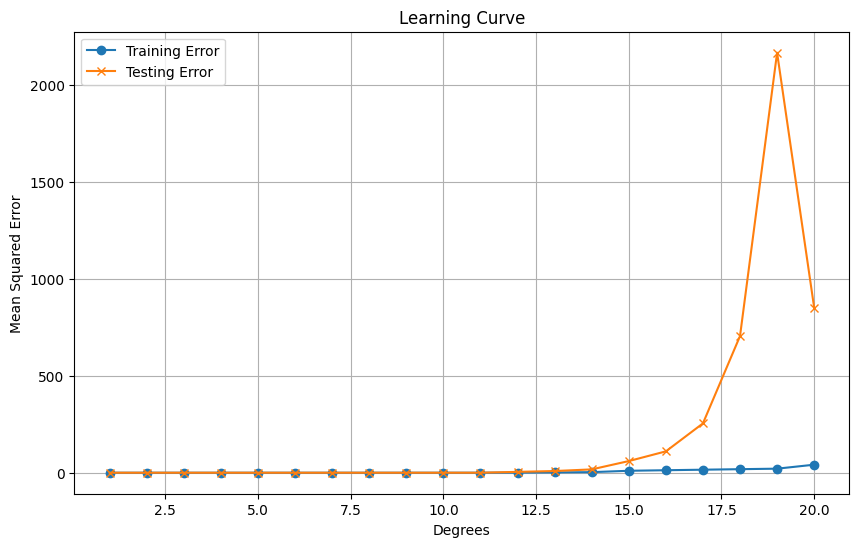

In [26]:
plt.figure(figsize=(10, 6))
plt.plot(degrees, trains, label='Training Error', marker='o')
plt.plot(degrees, tests, label='Testing Error', marker='x')
plt.title('Learning Curve')
plt.xlabel('Degrees')
plt.ylabel('Mean Squared Error')
plt.legend()
plt.grid(True)
plt.show()

## Fixing skew - Log transform for skewed features. 

In [3]:
from scipy.stats import skew
df1 = sns.load_dataset('titanic')
df = pd.read_csv('Titanic-dataset.csv')
print(f"Skew Before: {skew(df1['age'], nan_policy='omit')}")
print(f"Mean Before: {np.mean(df1['age'])}")
newage = np.log1p(df1['age'])
df1['newage'] = newage
df1.drop('age', axis=1, inplace=True)
print(f"Skew After: {skew(df1['newage'], nan_policy='omit')}")
print(f"Mean After: {np.mean(df1['newage'])}")


Skew Before: 0.3882898514698657
Mean Before: 29.69911764705882
Skew After: -1.873541618945743
Mean After: 3.258874036617909


## Correlations And Combining of Features

In [4]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['isAlone'] = (df['FamilySize'] == 1).astype(int)
names = df['Name'].str.extract(r'([A-Za-z]+)\.', expand=False)
from collections import Counter
dct = dict(Counter(list(names)))
rare = []
for key in dct.keys():
    if dct[key] < 3:
        rare.append(key)
rare
names.unique()

array(['Mr', 'Mrs', 'Miss', 'Master', 'Don', 'Rev', 'Dr', 'Mme', 'Ms',
       'Major', 'Lady', 'Sir', 'Mlle', 'Col', 'Capt', 'Countess',
       'Jonkheer'], dtype=object)

## Binning - Categorizing Vars

In [ ]:
pd.cut(df['Age'], bins=[0, 12, 18, 35, 60, 120], labels=['child','teen','adult','middle','senior'])


## Trying Stuff

## 1. LinearRegression
Applying Linearregression to non-linear data

In [ ]:
X = np.arange(1, 8)
y = -X ** 3 + 5 * X
model = LinearRegression()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)
model.fit(X_train.reshape(-1, 1), y_train)
# ======================================
y_train_pred = model.predict(X_train.reshape(-1, 1))
y_test_pred = model.predict(X_test.reshape(-1, 1))
plt.Figure(figsize=(16, 16))
plt.scatter(X, y)
plt.plot(X_train, y_train_pred, marker='x', label="training data")
plt.plot(X_test, y_test_pred, marker='o', label="testing data")
plt.title("Training vs testing on Polynomial dataset. ")
plt.xlabel("X data")
plt.ylabel("Predicted Y")
plt.legend()
plt.grid(True)
plt.show()


In [26]:
poly = PolynomialFeatures(degree=3)
X = np.arange(1, 20)
y = X**3 + np.random.randint(0, 5)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)
X_train_poly = poly.fit_transform(X_train.reshape(-1, 1))
X_test_poly = poly.fit_transform(X_test.reshape(-1, 1))

pipe = Pipeline([
    ('poly', PolynomialFeatures(degree=20)),
    ('lr', LinearRegression())
])

pipe.fit(X_train.reshape(-1, 1), y_train)
pred = pipe.predict(X_test.reshape(-1, 1))
r2_score(y_test, pred)
# lir = LinearRegression()
# lir.fit(X_train_poly, y_train)
# pred = lir.predict(X_test_poly)
# lir.score(X_test_poly, y_test) # <-----

-507000.9775219436

In [153]:
# Play around with pd using adult.csv file. 
# ====================================================================================
import pandas as pd
from collections import Counter
from itertools import chain
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.pipeline import make_pipeline
df = pd.read_csv('adult.csv')
enc_cols = list()
for column in df.columns:
    if df[column].nunique() < 10 and column != 'income':
        enc_cols.append(column)
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
ord = OrdinalEncoder(categories=[['<=50K', '>50K']])
df4 = pd.DataFrame(ord.fit_transform(df[['income']]), columns=ord.get_feature_names_out()) # Income column transformed. 
df2 = pd.DataFrame(ohe.fit_transform(df[enc_cols]), columns=ohe.get_feature_names_out()) # Encoded columns. 
df.drop(columns=['income'], inplace=True)
df = pd.concat([df, df2, df4], axis=1)
df.drop(columns=enc_cols, inplace=True)
df2 = df.copy()
imp = SimpleImputer(fill_value=0)
primary = ['7th-8th', '5th-6th', '1st-4th']
HS = ['9th', '12th', '11th', '10th']
for row in range(32561):
    if df2.loc[row, 'education'] in primary:
        df2.loc[row, 'primary'] = 1
    elif df2.loc[row, 'education'] in HS:
        df2.loc[row, 'HS'] = 1

df2.replace(list(chain.from_iterable(zip(primary, HS))), value=None, inplace=True)
# cat_enc = ['HS-grad', 'Some-college', 'Bachelors', 'Masters', 'Assoc-voc', 'Assoc-acdm', 'Prof-school', 'Doctorate', 'Preschool']
ohenc = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
nohenc = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
df3 = pd.DataFrame(ohenc.fit_transform(df2[['education']]), columns=ohenc.get_feature_names_out())
ddf3 = pd.DataFrame(nohenc.fit_transform(df2[['native.country']]), columns=nohenc.get_feature_names_out())
df2 = pd.concat([df2, df3, ddf3], axis=1)
df2.drop(columns=['education_None', 'education_10th'], inplace=True)
df2[['primary', 'HS']] = imp.fit_transform(df2[['primary', 'HS']])

df2.drop(columns=['education', 'occupation', 'native.country', 'native.country_?', 'workclass_?'], inplace=True)

X = df2.drop('income', axis=1)
y = df2['income']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)
regr = LogisticRegression()
model = make_pipeline(
    StandardScaler(),
    LogisticRegression()
)
model.fit(X_train, y_train)
pred = model.predict(X_test)
print(f"R2 Score: {accuracy_score(y_test, pred) * 100:.4f}")

R2 Score: 84.4406


In [10]:
model = LinearRegression()
# model = Ridge()
cal = fetch_california_housing()
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_validate(
    model, cal.data, cal.target, 
    scoring='r2', cv=kfold,
    return_train_score=True
)

print(list(scores.keys()))
print(f"{'='*55}\nTrain R2: {scores['train_score'].mean() * 100:.4f} ± {scores['train_score'].std():.4f}")
print(f"Test R2: {scores['test_score'].mean() * 100:.4f} ± {scores['test_score'].std():.4f}")

['fit_time', 'score_time', 'test_score', 'train_score']
Train R2: 60.6546 ± 0.0045
Test R2: 60.1378 ± 0.0170


In [12]:
bc = load_breast_cancer(return_X_y=True)
scaler = StandardScaler()
model = LogisticRegression(max_iter=10000)
y_pred = cross_val_predict(
    model, bc[0], bc[1],
    cv=5
)

accuracy_score(bc[1], y_pred)

0.9507908611599297

In [19]:
X, y = fetch_california_housing(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)
param_grid = {
    'alpha': [0.01, 0.1, 10, 100, 200]
}

grid = GridSearchCV(
    Ridge(),
    param_grid,
    scoring='neg_mean_squared_error',
    cv=5,
    n_jobs=-1
)

grid.fit(X_train, y_train)
pred = grid.predict(X_test)
grid.score(X_test, y_test)

-0.5221164709969186

In [21]:
param_dist = {'alpha': loguniform(0.01, 100)}
ran_grid = RandomizedSearchCV(
    Ridge(),
    param_dist,
    n_iter=10,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

ran_grid.fit(X_train, y_train)
ran_grid.score(X_test, y_test)

-0.5212552391586334

In [1]:
X, y = load_breast_cancer(return_X_y=True)
selector = SelectKBest(score_func=f_classif, k=10)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
pipe = Pipeline([
    ('selector', SelectKBest(score_func=f_classif, k=10)),
    ('clf', LogisticRegression(max_iter=1000))
])
pipe.fit(X_train, y_train)
pipe.score(X_test, y_test)

params = {'selector__k':[5, 10, 15, 20]}
gs = GridSearchCV(pipe, params, cv=5)
gs.fit(X_train, y_train)
gs.best_params_

# selector.fit(X_train, y_train)
# sel_X_train = selector.transform(X_train)
# sel_X_test = selector.transform(X_test)
# sel_X_train.shape
# feature_names = load_breast_cancer().feature_names
# feature_names[selector.get_support()]
# selector.scores_[selector.get_support()]

NameError: name 'load_breast_cancer' is not defined

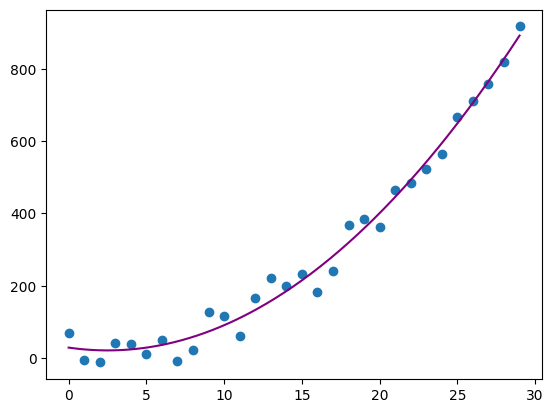

In [ ]:
X = np.arange(30)
y = X ** 2 + np.random.normal(0, 50, len(X))
pipe = Pipeline([
    ('poly', PolynomialFeatures(2)),
    ('scaler', StandardScaler()),
    ('regr', LinearRegression())
])
X_train, X_test, y_train, y_test = train_test_split(X.reshape(-1, 1), y, test_size=0.3)
pipe.fit(X_train, y_train)
y_test_pred = pipe.predict(X_test)
y_train_pred = pipe.predict(X_train)
r2_score(y_train, y_train_pred)

coefficients = np.polyfit(X, y, deg=2) 
polynomial = np.poly1d(coefficients)
X_smooth = np.linspace(X.min(), X.max(), 300)
y_trend = polynomial(X_smooth)
plt.scatter(X, y, label='Data')
plt.plot(X_smooth, y_trend, color='purple', label='Line of Best Fit')
plt.show() # just coz 😭😭

In [20]:
temp = df
temp

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize,isAlone
0,0,3,male,22.0,1,0,7.2500,S,2,0
1,1,1,female,38.0,1,0,71.2833,C,2,0
2,1,3,female,26.0,0,0,7.9250,S,1,1
3,1,1,female,35.0,1,0,53.1000,S,2,0
4,0,3,male,35.0,0,0,8.0500,S,1,1
...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,1,1
887,1,1,female,19.0,0,0,30.0000,S,1,1
888,0,3,female,NaN,1,2,23.4500,S,4,0
889,1,1,male,26.0,0,0,30.0000,C,1,1


In [16]:
# temp.dropna()
# temp.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1,  inplace=True)
ohe = OneHotEncoder(sparse_output=False)
df5 = pd.DataFrame(ohe.fit_transform(temp[['Sex', 'Embarked']]), columns=ohe.get_feature_names_out())
temp = pd.concat([temp, df5], axis=1).drop(columns=['Sex'], inplace=True)
temp

In [21]:
df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize,isAlone
0,0,3,male,22.0,1,0,7.2500,S,2,0
1,1,1,female,38.0,1,0,71.2833,C,2,0
2,1,3,female,26.0,0,0,7.9250,S,1,1
3,1,1,female,35.0,1,0,53.1000,S,2,0
4,0,3,male,35.0,0,0,8.0500,S,1,1
...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,1,1
887,1,1,female,19.0,0,0,30.0000,S,1,1
888,0,3,female,NaN,1,2,23.4500,S,4,0
889,1,1,male,26.0,0,0,30.0000,C,1,1


In [ ]:
X, y = load_iris(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)
param_grid = {
    'solver': ['lbfgs', 'liblinear'],
    'C': [2, 5, 10, 20, 50],
    'max_iter': [100, 200, 500, 1000]
}
grid = GridSearchCV(
    LogisticRegression(),
    param_grid,
    cv = 5,
)
grid.fit(X_train, y_train)
grid.score(X_test, y_test)
grid.best_params_

In [12]:
model = LogisticRegression()
model.fit(X_train, y_train)
pred = model.predict_proba(X_test)
pred[:5]

array([[2.02813417e-02, 9.49601950e-01, 3.01167081e-02],
       [9.80516511e-01, 1.94832787e-02, 2.10844241e-07],
       [9.94552327e-01, 5.44765455e-03, 1.82097220e-08],
       [2.21921600e-06, 2.81596499e-02, 9.71838131e-01],
       [1.04967977e-03, 5.93329591e-01, 4.05620729e-01]])

In [33]:
X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)
lr = LogisticRegression(max_iter=4000)
lr.fit(X_train, y_train)
y_pred = lr.predict_proba(X_test)
y_pred[y_pred >= 0.35] = 1
y_pred[y_pred < 0.35] = 0
accuracy_score(y_test, y_pred[:, 1])

0.9532163742690059

In [ ]:
# Logistic Regression Metrics. 
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
)
import matplotlib.pyplot as plt
import numpy as np

# ── Data & model ──────────────────────────────────────────────
iris = load_iris()
X, y = iris.data, iris.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

preds = model.predict(X_test)
probs = model.predict_proba(X_test)

# ── Individual metrics ────────────────────────────────────────
print("Accuracy: ", accuracy_score(y_test, preds))
# 1.0

# average='macro'   → mean across classes (treats all equally)
# average='weighted'→ mean weighted by class support (use for imbalanced data)
print("Precision:", precision_score(y_test, preds, average='macro'))
print("Recall:   ", recall_score(y_test, preds, average='macro'))
print("F1:       ", f1_score(y_test, preds, average='macro'))

# ── Full report (per-class breakdown) ─────────────────────────
print(classification_report(y_test, preds, target_names=iris.target_names))
#                  precision    recall  f1-score   support
#
#          setosa       1.00      1.00      1.00        10
#      versicolor       1.00      1.00      1.00         9
#       virginica       1.00      1.00      1.00        11
#
#        accuracy                           1.00        30
#       macro avg       1.00      1.00      1.00        30
#    weighted avg       1.00      1.00      1.00        30

# ── Confusion matrix ──────────────────────────────────────────
cm = confusion_matrix(y_test, preds)
print(cm)
# [[10  0  0]
#  [ 0  9  0]
#  [ 0  0 11]]

disp = ConfusionMatrixDisplay(cm, display_labels=iris.target_names)
disp.plot(cmap='Blues')
plt.title("Confusion matrix")
plt.tight_layout()
plt.show()

# ── ROC-AUC (multiclass → one-vs-rest) ───────────────────────
auc = roc_auc_score(y_test, probs, multi_class='ovr')
print("ROC-AUC (macro OvR):", round(auc, 4))
# 1.0

# ROC curve per class
fig, ax = plt.subplots()
for i, class_name in enumerate(iris.target_names):
    fpr, tpr, _ = roc_curve((y_test == i).astype(int), probs[:, i])
    ax.plot(fpr, tpr, label=f"{class_name} (AUC={roc_auc_score((y_test==i).astype(int), probs[:,i]):.2f})")

ax.plot([0,1],[0,1], 'k--', linewidth=0.8)
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_title("ROC curve (one-vs-rest)")
ax.legend()
plt.tight_layout()
plt.show()

# ── Imbalanced dataset demo ───────────────────────────────────
# Simulate: 95% class 0, 5% class 1
from sklearn.datasets import make_classification
Xb, yb = make_classification(n_samples=1000, weights=[0.95, 0.05], random_state=42)
Xb_train, Xb_test, yb_train, yb_test = train_test_split(Xb, yb, test_size=0.2)

dummy = LogisticRegression()
dummy.fit(Xb_train, yb_train)
all_zeros = np.zeros_like(yb_test)   # "predict all 0s" baseline

print("\n── Imbalanced demo ──")
print("Accuracy (all zeros): ", accuracy_score(yb_test, all_zeros))      # ~0.95 — misleading!
print("F1       (all zeros): ", f1_score(yb_test, all_zeros))            # 0.0   — exposed
print("Accuracy (model):     ", accuracy_score(yb_test, dummy.predict(Xb_test)))
print("F1       (model):     ", f1_score(yb_test, dummy.predict(Xb_test)))

In [2]:
X, y = load_iris(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
accuracy_score(y_test, knn.predict(X_test))

0.9777777777777777